# Tech Challenge FIAP - Fase 1: Etapa 1
# Análise Exploratória de Dados (EDA) e Modelos Baseline

**Projeto:** Previsão de Churn em Telecomunicações 
**Data:** Abril 2026 

## Objetivo

Este notebook implementa a **Etapa 1** do Tech Challenge, focando em:

1. **Entendimento do Problema de Negócio** (ML Canvas)
2. **Análise Exploratória de Dados (EDA)**
 - Volume, qualidade, distribuição
 - Data readiness
3. **Definição de Métricas**
 - Técnicas: AUC-ROC, PR-AUC, F1, F2
 - Negócio: Custo de churn evitado
4. **Modelos Baseline**
 - DummyClassifier
 - Regressão Logística
5. **Tracking com MLflow**

## Referências
- Ciclo de Vida, Aula 01 (CRISP-DM, Business Understanding)
- Ciclo de Vida, Aula 02 (EDA, MVP de Modelos, MLflow)
- Fundamentos, Aulas 01-02 (Modelos baseline)

---
## 1. Setup e Configuração Inicial

In [1]:
# Bibliotecas básicas
import numpy as np
import pandas as pd
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Estatística
from scipy import stats

# Utilitários
from pathlib import Path
import os

# Configurar seed para reprodutibilidade
np.random.seed(42)

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("=" * 80)
print("CONFIGURAÇÃO DO AMBIENTE")
print("=" * 80)
print(f"\n Bibliotecas importadas com sucesso!")
print(f"\n Versões:")
print(f" - NumPy: {np.__version__}")
print(f" - Pandas: {pd.__version__}")
print(f" - Matplotlib: {plt.matplotlib.__version__}")
print(f" - Seaborn: {sns.__version__}")
print(f"\n Estilo de visualização: whitegrid")
print(f" Random seed: 42")

CONFIGURAÇÃO DO AMBIENTE

 Bibliotecas importadas com sucesso!

 Versões:
 - NumPy: 2.4.4
 - Pandas: 2.3.3
 - Matplotlib: 3.10.9
 - Seaborn: 0.13.2

 Estilo de visualização: whitegrid
 Random seed: 42


---
## 2. Carregamento dos Dados

### Sobre o Dataset: Telco Customer Churn

**Fonte:** IBM Sample Data Sets - [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) 
**Contexto de Negócio:** Uma operadora de telecomunicações deseja prever quais clientes estão em risco de cancelar seus serviços (churn) para tomar ações preventivas de retenção.

**Características do Dataset:**
- **Observações:** 7.043 clientes
- **Features:** 20 variáveis independentes + 1 variável target
- **Tipo de Problema:** Classificação binária (Churn: Yes/No)
- **Período:** Dados de clientes ativos e cancelados

### Dicionário de Dados

#### **Variáveis Demográficas**
- **customerID**: Identificador único do cliente
- **gender**: Gênero (Male/Female)
- **SeniorCitizen**: Cliente idoso? (0=Não, 1=Sim)
- **Partner**: Tem parceiro/cônjuge? (Yes/No)
- **Dependents**: Tem dependentes? (Yes/No)

#### **Serviços de Telefonia**
- **PhoneService**: Tem serviço telefônico? (Yes/No)
- **MultipleLines**: Múltiplas linhas telefônicas? (Yes/No/No phone service)

#### **Serviços de Internet**
- **InternetService**: Tipo de internet (DSL/Fiber optic/No)
- **OnlineSecurity**: Serviço de segurança online (Yes/No/No internet service)
- **OnlineBackup**: Serviço de backup online (Yes/No/No internet service)
- **DeviceProtection**: Proteção de dispositivos (Yes/No/No internet service)
- **TechSupport**: Suporte técnico (Yes/No/No internet service)
- **StreamingTV**: Streaming de TV (Yes/No/No internet service)
- **StreamingMovies**: Streaming de filmes (Yes/No/No internet service)

#### **Informações Contratuais e Financeiras**
- **tenure**: Meses que o cliente está com a empresa (0-72 meses) 
 *Importância: Clientes novos (baixo tenure) tendem a fazer churn com mais frequência*
- **Contract**: Tipo de contrato
 - *Month-to-month*: Sem compromisso (maior risco de churn)
 - *One year*: Compromisso de 1 ano
 - *Two year*: Compromisso de 2 anos (maior fidelidade)
- **PaperlessBilling**: Fatura eletrônica? (Yes/No)
- **PaymentMethod**: Forma de pagamento
 - Electronic check
 - Mailed check
 - Bank transfer (automatic)
 - Credit card (automatic)
- **MonthlyCharges**: Valor mensal pago (USD 18-119)
- **TotalCharges**: Total acumulado pago pelo cliente (USD) 
 *Cálculo aproximado: tenure × MonthlyCharges* 
 *Nota: Contém 11 valores vazios (clientes muito novos sem histórico de pagamento)*

#### **Variável Target**
- **Churn**: Cliente cancelou o serviço? (Yes/No) 
 *Esta é a variável que queremos prever!*

### 2.1. Carregar Dataset

```markdown
O dataset será carregado e inspecionado para:
1. Verificar dimensões (linhas × colunas)
2. Identificar tipos de dados
3. Detectar valores ausentes
4. Entender a estrutura geral
```

In [2]:
# Carregar dados
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

---
## 3. Análise Exploratória de Dados (EDA)

### Objetivos da EDA

A Análise Exploratória de Dados é fundamental para:
1. **Qualidade dos Dados**: Identificar valores ausentes, duplicados e inconsistências
2. **Distribuições**: Entender a distribuição de variáveis numéricas e categóricas
3. **Outliers**: Detectar valores extremos que podem impactar o modelo
4. **Correlações**: Identificar relacionamentos entre features e com o target
5. **Balanceamento**: Avaliar a distribuição da variável target (Churn)
6. **Data Readiness**: Determinar quais transformações são necessárias

### 3.1. Visão Geral do Dataset

In [3]:
# Primeiras linhas
print("=" * 80)
print("PRIMEIRAS 10 LINHAS DO DATASET")
print("=" * 80)
df.head(10)

PRIMEIRAS 10 LINHAS DO DATASET


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
# Informações gerais
print("=" * 80)
print("INFORMAÇÕES GERAIS DO DATASET")
print("=" * 80)
print(f"\n Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"\n Memória utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

print("\n Tipos de dados:")
print(df.dtypes.value_counts())

print("\n Informações detalhadas:")
df.info()

print("\n Estatísticas descritivas:")
df.describe()

INFORMAÇÕES GERAIS DO DATASET

 Dimensões: 7,043 linhas x 21 colunas

 Memória utilizada: 6.82 MB


 Tipos de dados:
object     18
int64       2
float64     1
Name: count, dtype: int64

 Informações detalhadas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


### 3.2. Qualidade dos Dados

Análise de **dados faltantes**, **duplicados** e **valores inconsistentes**.

In [5]:
print("=" * 80)
print("ANÁLISE DE QUALIDADE DOS DADOS")
print("=" * 80)

# Dados faltantes
print("\n DADOS FALTANTES:")
missing = df.isnull().sum()
missing_pct = ((missing / len(df)) * 100).round(2)
missing_values = pd.DataFrame({
    'Coluna': missing.index,
    'Valores Faltantes': missing.values,
    'Percentual (%)': missing_pct.values
})

missing_values = missing_values[missing_values['Valores Faltantes'] > 0].sort_values(
    by='Percentual (%)', ascending=False
)

if len(missing_values) > 0:
    print(missing_values.to_string(index=False))
    # Visualização

    fig, ax = plt.subplots(figsize=(10, 6))

    missing_values.plot(kind='barh', x='Coluna', y='Percentual (%)', ax=ax, color='coral')

    ax.set_xlabel('Percentual de Valores Faltantes (%)')

    ax.set_title('Dados Faltantes por Coluna', fontsize=14, fontweight='bold')

    plt.tight_layout()

    plt.show()

else:
    print(" Nenhum valor faltante encontrado!")


# Duplicados
print("\n REGISTROS DUPLICADOS:")
duplicates = df.duplicated().sum()
print(f" - Total de linhas duplicadas: {duplicates} ({duplicates/len(df)*100:.2f}%)")

if duplicates > 0:
    print("\n Registros duplicados encontrados:")
    print(df[df.duplicated(keep=False)].head(10))

else:
    print(" Nenhuma duplicata encontrada!")

ANÁLISE DE QUALIDADE DOS DADOS

 DADOS FALTANTES:
 Nenhum valor faltante encontrado!

 REGISTROS DUPLICADOS:
 - Total de linhas duplicadas: 0 (0.00%)
 Nenhuma duplicata encontrada!


### 3.3. Análise da Variável Target (Churn)

ANÁLISE DA VARIÁVEL TARGET: CHURN

 Coluna target identificada: 'Churn'

 Distribuição do Churn:
       Classe  Contagem  Percentual (%)
Não Churn (0)      5174           73.46
    Churn (1)      1869           26.54

 Razão de desbalanceamento: 2.77:1
 Dataset DESBALANCEADO! Considerar técnicas de balanceamento.


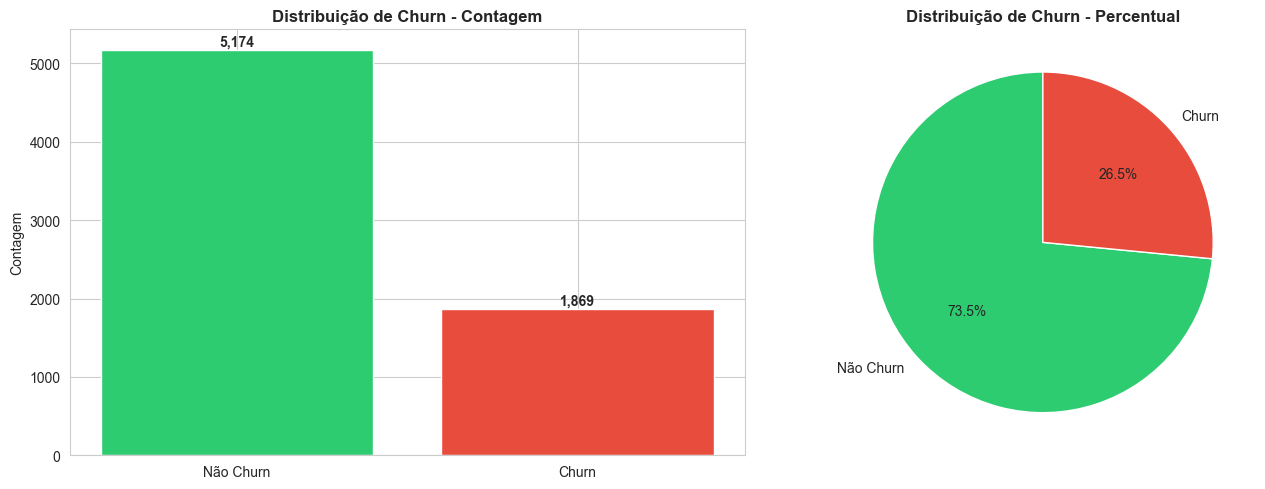

In [6]:
print("=" * 80)
print("ANÁLISE DA VARIÁVEL TARGET: CHURN")
print("=" * 80)

# Identificar coluna de churn
churn_col = None
for col in df.columns:
    if 'churn' in col.lower():
        churn_col = col
        break

if churn_col:
    print(f"\n Coluna target identificada: '{churn_col}'")
    print(f"\n Distribuição do Churn:")
    
    # Se for categórica, converter para binária
    if df[churn_col].dtype == 'object':
        df['churn_binary'] = df[churn_col].map({'Yes': 1, 'No': 0})
        target_col = 'churn_binary'
    else:
        target_col = churn_col
    
    # Contagem
    churn_counts = df[target_col].value_counts().sort_index()
    churn_pct = df[target_col].value_counts(normalize=True).sort_index() * 100
    
    summary_df = pd.DataFrame({
        'Classe': ['Não Churn (0)', 'Churn (1)'],
        'Contagem': churn_counts.values,
        'Percentual (%)': churn_pct.values
    })
    print(summary_df.to_string(index=False))
    
    # Desbalanceamento
    imbalance_ratio = churn_counts.max() / churn_counts.min()
    print(f"\n Razão de desbalanceamento: {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 2:
        print(" Dataset DESBALANCEADO! Considerar técnicas de balanceamento.")
    else:
        print(" Dataset razoavelmente balanceado.")
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico de barras
    axes[0].bar(['Não Churn', 'Churn'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
    axes[0].set_ylabel('Contagem')
    axes[0].set_title('Distribuição de Churn - Contagem', fontweight='bold')
    for i, v in enumerate(churn_counts.values):
        axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
    
    # Gráfico de pizza
    axes[1].pie(churn_pct.values, labels=['Não Churn', 'Churn'], autopct='%1.1f%%',
                colors=['#2ecc71', '#e74c3c'], startangle=90)
    axes[1].set_title('Distribuição de Churn - Percentual', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
else:
    print(" Coluna de churn não identificada automaticamente.")
    print(f"Colunas disponíveis: {df.columns.tolist()}")

### 3.4. Estatísticas Descritivas

In [7]:
print("=" * 80)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 80)

# Separar variáveis numéricas e categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n Variáveis numéricas: {len(numeric_cols)}")
print(f" Variáveis categóricas: {len(categorical_cols)}")

# Estatísticas de variáveis numéricas
if len(numeric_cols) > 0:
    print("\n VARIÁVEIS NUMÉRICAS:")
    display(df[numeric_cols].describe().T)

# Estatísticas de variáveis categóricas
if len(categorical_cols) > 0:
    print("\n VARIÁVEIS CATEGÓRICAS:")
    
    cat_summary = []
    
    for col in categorical_cols:
        unique_vals = df[col].nunique()
        most_common = df[col].mode()[0] if len(df[col].mode()) > 0 else None
        most_common_pct = (df[col] == most_common).sum() / len(df) * 100
        
        cat_summary.append({
            'Variável': col,
            'Valores Únicos': unique_vals,
            'Valor Mais Comum': most_common,
            'Frequência (%)': most_common_pct
        })
    
    cat_df = pd.DataFrame(cat_summary)
    display(cat_df)

ESTATÍSTICAS DESCRITIVAS

 Variáveis numéricas: 4
 Variáveis categóricas: 18

 VARIÁVEIS NUMÉRICAS:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.00,0.16,0.37,0.00,0.00,0.00,0.00,1.00
tenure,7043.00,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.00,64.76,30.09,18.25,35.50,70.35,89.85,118.75
churn_binary,7043.00,0.27,0.44,0.00,0.00,0.00,1.00,1.00



 VARIÁVEIS CATEGÓRICAS:


,Variável,Valores Únicos,Valor Mais Comum,Frequência (%)
0,customerID,7043,0002-ORFBO,0.01
1,gender,2,Male,50.48
2,Partner,2,No,51.70
3,Dependents,2,No,70.04
4,PhoneService,2,Yes,90.32
5,MultipleLines,3,No,48.13
6,InternetService,3,Fiber optic,43.96
7,OnlineSecurity,3,No,49.67
8,OnlineBackup,3,No,43.84
9,DeviceProtection,3,No,43.94


### 3.5. Análise de Outliers

ANÁLISE DE OUTLIERS

 Resumo de Outliers (método IQR):


,Variável,Outliers,Percentual (%),Limite Inferior,Limite Superior
0,tenure,0,0.00,-60.00,124.00
1,MonthlyCharges,0,0.00,-46.02,171.38


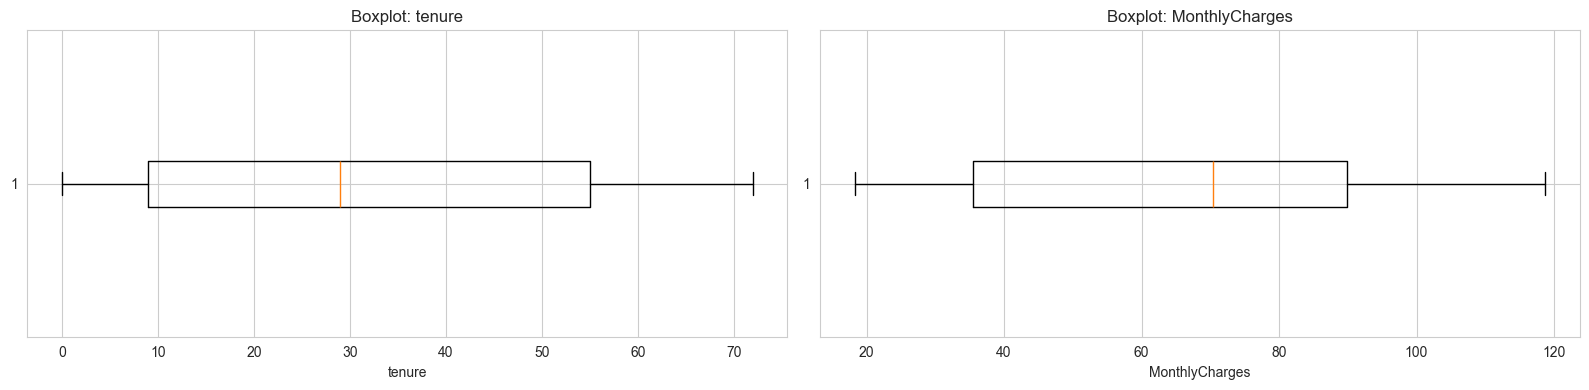

In [8]:
print("=" * 80)
print("ANÁLISE DE OUTLIERS")
print("=" * 80)

if len(numeric_cols) > 0:
    # Remover colunas binárias e de ID
    numeric_cols_filtered = [col for col in numeric_cols 
                             if col not in ['churn_binary'] 
                             and 'id' not in col.lower()
                             and df[col].nunique() > 2]
    
    if len(numeric_cols_filtered) > 0:
        # Calcular outliers usando IQR
        outlier_summary = []
        
        for col in numeric_cols_filtered[:10]:  # Limitar a 10 colunas
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
            outlier_pct = (outliers / len(df)) * 100
            
            outlier_summary.append({
                'Variável': col,
                'Outliers': outliers,
                'Percentual (%)': outlier_pct,
                'Limite Inferior': lower_bound,
                'Limite Superior': upper_bound
            })
        
        outlier_df = pd.DataFrame(outlier_summary)
        print("\n Resumo de Outliers (método IQR):")
        display(outlier_df)
        
        # Visualização - Boxplots
        n_cols = min(4, len(numeric_cols_filtered))
        n_rows = (len(numeric_cols_filtered) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
        axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
        
        for idx, col in enumerate(numeric_cols_filtered[:12]):
            if idx < len(axes):
                axes[idx].boxplot(df[col].dropna(), vert=False)
                axes[idx].set_xlabel(col)
                axes[idx].set_title(f'Boxplot: {col}')
        
        # Remover axes vazios
        for idx in range(len(numeric_cols_filtered), len(axes)):
            fig.delaxes(axes[idx])
        
        plt.tight_layout()
        plt.show()
    
    else:
        print("\n Nenhuma variável numérica adequada para análise de outliers.")

else:
    print("\n Nenhuma variável numérica encontrada.")

### 3.6. Análise de Correlação

ANÁLISE DE CORRELAÇÃO


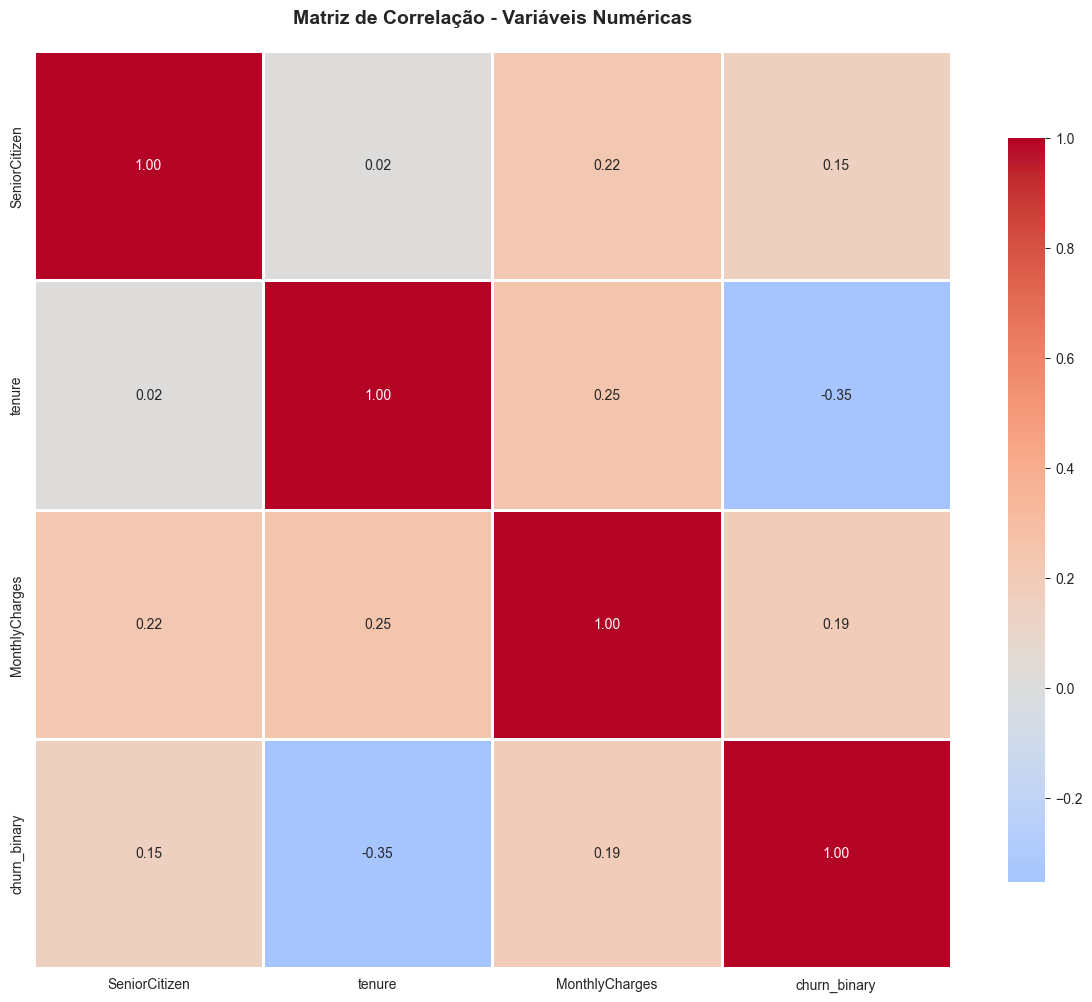


 Correlação com Target (Churn):
churn_binary      1.00
MonthlyCharges    0.19
SeniorCitizen     0.15
tenure           -0.35


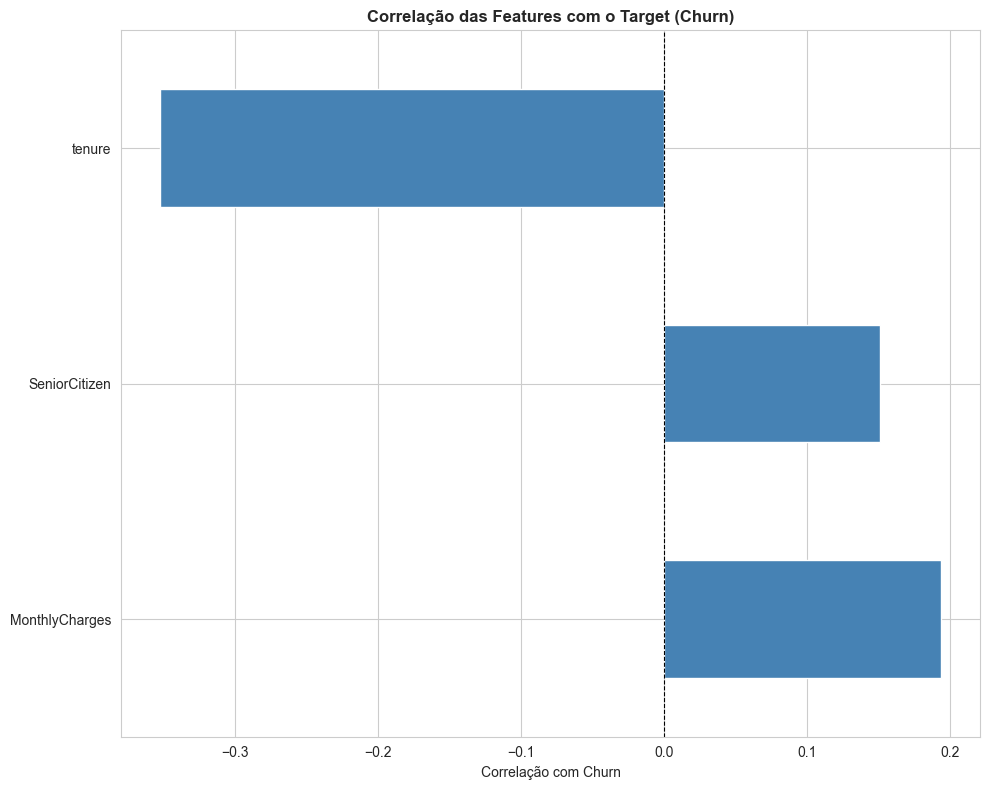

In [9]:
print("=" * 80)
print("ANÁLISE DE CORRELAÇÃO")
print("=" * 80)

if len(numeric_cols) > 1:
    # Calcular correlação
    corr_matrix = df[numeric_cols].corr()
    
    # Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlação - Variáveis Numéricas', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Correlações com target (se existir)
    if 'churn_binary' in numeric_cols:
        print("\n Correlação com Target (Churn):")
        target_corr = corr_matrix['churn_binary'].sort_values(ascending=False)
        print(target_corr.to_string())
        
        # Visualização
        fig, ax = plt.subplots(figsize=(10, 8))
        target_corr[target_corr.index != 'churn_binary'].plot(kind='barh', ax=ax, color='steelblue')
        ax.set_xlabel('Correlação com Churn')
        ax.set_title('Correlação das Features com o Target (Churn)', fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
        plt.tight_layout()
        plt.show()

else:
    print("\n Insuficientes variáveis numéricas para análise de correlação.")

---
## 4. Preparação dos Dados para Modelagem

### Estratégia de Preparação

Nesta etapa, aplicaremos as seguintes transformações:

#### **1. Tratamento de Valores Ausentes**
- **TotalCharges**: Contém 11 valores vazios (string vazia)
 - **Decisão**: Converter para numérico NaN Imputar com **mediana**
 - **Justificativa**: Mediana é mais robusta que média contra outliers
 - **Alternativa considerada**: Calcular como `tenure × MonthlyCharges` (mais preciso, mas para fins didáticos usaremos imputação)

#### **2. Encoding de Variáveis Categóricas**
- **Binary Encoding** (Yes/No, Male/Female):
 - Convertidos para 0/1 usando mapeamento direto
- **One-Hot Encoding** (Multi-classe):
 - `MultipleLines`, `InternetService`, `Contract`, `PaymentMethod`, etc.
 - **Estratégia**: `drop_first=False` inicialmente para análise completa
 - **Nota**: Em produção, considerar `drop_first=True` para evitar multicolinearidade

#### **3. Remoção de Colunas**
- **customerID**: Identificador único sem valor preditivo
- **Churn** (original): Será convertida para `churn_binary` (0/1)

#### **4. Prevenção de Data Leakage**
- **IMPORTANTE**: Todo pré-processamento estatístico (scaling, imputação com média/mediana) será feito APÓS o split treino/teste
- **Nesta seção**: Apenas transformações determinísticas (encoding, conversão de tipos)

### 4.1. Tratamento de Dados Faltantes e Inconsistências

In [10]:
print("=" * 80)
print("PREPARAÇÃO DOS DADOS")
print("=" * 80)

# Criar cópia para processamento
df_processed = df.copy()

# Se existir coluna 'TotalCharges' como string (comum no dataset Telco), converter para numérico
if 'TotalCharges' in df_processed.columns:
    print("\n Convertendo 'TotalCharges' para numérico...")
    df_processed['TotalCharges'] = pd.to_numeric(df_processed['TotalCharges'], errors='coerce')
    print(f" - Valores convertidos para numérico: {df_processed['TotalCharges'].isna().sum()}")

# Tratamento de valores faltantes
missing_cols = df_processed.columns[df_processed.isnull().any()].tolist()
if len(missing_cols) > 0:
    print(f"\n Tratando valores faltantes em {len(missing_cols)} colunas...")
    
    for col in missing_cols:
        if df_processed[col].dtype in [np.float64, np.int64]:
            # Imputar com mediana
            median_val = df_processed[col].median()
            df_processed[col].fillna(median_val, inplace=True)
            print(f" - {col}: imputado com mediana ({median_val:.2f})")
        else:
            # Imputar com moda
            mode_val = df_processed[col].mode()[0]
            df_processed[col].fillna(mode_val, inplace=True)
            print(f" - {col}: imputado com moda ({mode_val})")

else:
    print("\n Nenhum valor faltante para tratar.")

print(f"\n Dataset processado: {df_processed.shape}")

PREPARAÇÃO DOS DADOS

 Convertendo 'TotalCharges' para numérico...
 - Valores convertidos para numérico: 11

 Tratando valores faltantes em 1 colunas...
 - TotalCharges: imputado com mediana (1397.47)

 Dataset processado: (7043, 22)


### 4.2. Feature Engineering e Encoding

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

# Identificar colunas para remover (ID, target original)
cols_to_drop = []
for col in df_processed.columns:
    if 'id' in col.lower() and col != 'SeniorCitizen':
        cols_to_drop.append(col)

if churn_col and churn_col != 'churn_binary':
    cols_to_drop.append(churn_col)

print(f"\n Removendo colunas: {cols_to_drop}")
df_processed = df_processed.drop(columns=cols_to_drop, errors='ignore')

# Label Encoding para variáveis categóricas binárias
binary_cols = []
for col in df_processed.select_dtypes(include=['object']).columns:
    if df_processed[col].nunique() == 2:
        binary_cols.append(col)

if len(binary_cols) > 0:
    print(f"\n Label Encoding para {len(binary_cols)} variáveis binárias:")
    le = LabelEncoder()
    
    for col in binary_cols:
        df_processed[col] = le.fit_transform(df_processed[col])
        print(f" - {col}")

# One-Hot Encoding para variáveis categóricas com múltiplas categorias
categorical_cols_remaining = df_processed.select_dtypes(include=['object']).columns.tolist()
if len(categorical_cols_remaining) > 0:
    print(f"\n One-Hot Encoding para {len(categorical_cols_remaining)} variáveis categóricas:")
    
    for col in categorical_cols_remaining:
        print(f" - {col}")
    
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols_remaining, drop_first=True)

print(f"\n Dataset após encoding: {df_processed.shape}")
print(f"\n Colunas finais ({len(df_processed.columns)}):")
print(df_processed.columns.tolist())

FEATURE ENGINEERING

 Removendo colunas: ['customerID', 'Churn']

 Label Encoding para 5 variáveis binárias:
 - gender
 - Partner
 - Dependents
 - PhoneService
 - PaperlessBilling

 One-Hot Encoding para 10 variáveis categóricas:
 - MultipleLines
 - InternetService
 - OnlineSecurity
 - OnlineBackup
 - DeviceProtection
 - TechSupport
 - StreamingTV
 - StreamingMovies
 - Contract
 - PaymentMethod

 Dataset após encoding: (7043, 31)

 Colunas finais (31):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'churn_binary', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes'

### 4.3. Separação Features e Target

In [12]:
print("=" * 80)
print("SEPARAÇÃO FEATURES E TARGET")
print("=" * 80)

# Definir target
target_column = 'churn_binary' if 'churn_binary' in df_processed.columns else None

if target_column:
    y = df_processed[target_column]
    X = df_processed.drop(columns=[target_column])
    
    print(f"\n Separação concluída:")
    print(f" - Features (X): {X.shape}")
    print(f" - Target (y): {y.shape}")
    print(f"\n Distribuição do target:")
    print(y.value_counts())

else:
    print("\n Coluna target não encontrada. Usando todas as colunas como features.")
    X = df_processed
    y = None

SEPARAÇÃO FEATURES E TARGET

 Separação concluída:
 - Features (X): (7043, 30)
 - Target (y): (7043,)

 Distribuição do target:
churn_binary
0    5174
1    1869
Name: count, dtype: int64


### 4.4. Divisão Treino/Teste e Padronização

#### Estratégia de Divisão

**Configurações:**
- **Test size**: 20% dos dados (1.409 amostras)
- **Train size**: 80% dos dados (5.634 amostras)
- **Stratify**: `stratify=y` para manter a proporção de churn em ambos os conjuntos
- **Random state**: 42 para reprodutibilidade

**Justificativas:**
1. **Split estratificado**: Essencial em problemas desbalanceados (churn ~27%)
2. **80/20 split**: Padrão da indústria, balanceia treino suficiente vs. validação confiável
3. **Seed fixado**: Garante que experimentos sejam comparáveis

#### Padronização (StandardScaler)

**Por que padronizar?**
- Modelos baseados em distância (Regressão Logística, SVM, KNN) são sensíveis a escalas
- Features como `TotalCharges` (0-8.000) dominariam sobre `SeniorCitizen` (0-1)
- StandardScaler: transforma para média=0 e desvio padrão=1

**IMPORTANTE - Prevenção de Data Leakage:**
1. **Fit apenas no treino**: `scaler.fit(X_train)`
2. **Transform em ambos**: `scaler.transform(X_train)` e `scaler.transform(X_test)`
3. **NUNCA fazer**: `scaler.fit(X_test)` - isso vazaria informação do teste para o treino!

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=" * 80)
print("DIVISÃO TREINO/TESTE E PADRONIZAÇÃO")
print("=" * 80)

# Divisão estratificada
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42,
        stratify=y
    )
    
    print(f"\n Divisão estratificada concluída:")
    print(f" - Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
    print(f" - Teste: {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")
    
    print(f"\n Distribuição do target no treino:")
    print(y_train.value_counts())
    print(f"\n Distribuição do target no teste:")
    print(y_test.value_counts())
    
    # Padronização (StandardScaler)
    print(f"\n Aplicando StandardScaler...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Converter de volta para DataFrame (opcional, para manter nomes de colunas)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    print(f" Padronização concluída!")
    print(f"\n Estatísticas após padronização (treino):")
    print(f" - Média: {X_train_scaled.mean().mean():.6f}")
    print(f" - Desvio padrão: {X_train_scaled.std().mean():.6f}")

else:
    print("\n Target não definido. Pulando divisão treino/teste.")

DIVISÃO TREINO/TESTE E PADRONIZAÇÃO

 Divisão estratificada concluída:
 - Treino: 5634 amostras (80.0%)
 - Teste: 1409 amostras (20.0%)

 Distribuição do target no treino:
churn_binary
0    4139
1    1495
Name: count, dtype: int64

 Distribuição do target no teste:
churn_binary
0    1035
1     374
Name: count, dtype: int64

 Aplicando StandardScaler...
 Padronização concluída!

 Estatísticas após padronização (treino):
 - Média: -0.000000
 - Desvio padrão: 1.000089


---
## 5. Definição de Métricas

### 5.1. Métricas Técnicas

In [14]:
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score, fbeta_score,

roc_auc_score, average_precision_score, confusion_matrix,

classification_report, roc_curve, precision_recall_curve

)

print("=" * 80)
print("DEFINIÇÃO DE MÉTRICAS")
print("=" * 80)

print("""
MÉTRICAS TÉCNICAS SELECIONADAS:


1. AUC-ROC (Area Under ROC Curve)
- Meta: ≥ 0.80

- Mede a capacidade geral de discriminação do modelo

- Robusto a desbalanceamento de classes


2. Precision-Recall AUC (PR-AUC)
- Meta: ≥ 0.65

- Mais apropriada para datasets desbalanceados

- Foca na performance da classe minoritária (churn)


3. Recall (Sensibilidade)
- Meta: ≥ 0.75

- PRIORIDADE: Identificar o máximo de clientes em risco

- Minimizar Falsos Negativos (custo alto de perder cliente)


4. F2-Score
- Meta: ≥ 0.70

- F2 pondera mais Recall que Precision (β=2)

- Alinhado com a estratégia de negócio


5. Precision
- Secundária, mas importante para não sobrecarregar equipe de retenção

- Minimizar Falsos Positivos (custo de ação desnecessária)


MÉTRICAS DE NEGÓCIO:


Custo-Benefício por Predição:
- Verdadeiro Positivo (TP): +R$ 400 (cliente retido)

- Falso Positivo (FP): -R$ 50 (ação desnecessária)

- Falso Negativo (FN): -R$ 500 (cliente perdido)

- Verdadeiro Negativo (TN): R$ 0


Fórmula do Valor Esperado:
Valor Total = (TP × 400) - (FP × 50) - (FN × 500)


TRADE-OFF:

Falsos Negativos são 10x mais custosos que Falsos Positivos!

Estratégia: Priorizar RECALL para minimizar perda de clientes.

""")

DEFINIÇÃO DE MÉTRICAS

MÉTRICAS TÉCNICAS SELECIONADAS:


1. AUC-ROC (Area Under ROC Curve)
- Meta: ≥ 0.80

- Mede a capacidade geral de discriminação do modelo

- Robusto a desbalanceamento de classes


2. Precision-Recall AUC (PR-AUC)
- Meta: ≥ 0.65

- Mais apropriada para datasets desbalanceados

- Foca na performance da classe minoritária (churn)


3. Recall (Sensibilidade)
- Meta: ≥ 0.75

- PRIORIDADE: Identificar o máximo de clientes em risco

- Minimizar Falsos Negativos (custo alto de perder cliente)


4. F2-Score
- Meta: ≥ 0.70

- F2 pondera mais Recall que Precision (β=2)

- Alinhado com a estratégia de negócio


5. Precision
- Secundária, mas importante para não sobrecarregar equipe de retenção

- Minimizar Falsos Positivos (custo de ação desnecessária)


MÉTRICAS DE NEGÓCIO:


Custo-Benefício por Predição:
- Verdadeiro Positivo (TP): +R$ 400 (cliente retido)

- Falso Positivo (FP): -R$ 50 (ação desnecessária)

- Falso Negativo (FN): -R$ 500 (cliente perdido)

- Verdadeiro Ne

### 5.2. Função de Avaliação Customizada

In [15]:
def evaluate_model(y_true, y_pred, y_pred_proba=None, model_name="Model"):
    """
    Avalia um modelo de classificação com métricas técnicas e de negócio.
    
    Args:
        y_true: Valores reais do target
        y_pred: Predições binárias do modelo
        y_pred_proba: Probabilidades preditas (para AUC-ROC e PR-AUC)
        model_name: Nome do modelo para exibição
    
    Returns:
        dict: Dicionário com todas as métricas calculadas
    """
    print("=" * 80)
    print(f"AVALIAÇÃO DO MODELO: {model_name}")
    print("=" * 80)
    
    # Métricas técnicas básicas
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    
    metrics = {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'f2_score': f2
    }
    
    # Métricas baseadas em probabilidades (se disponíveis)
    if y_pred_proba is not None:
        auc_roc = roc_auc_score(y_true, y_pred_proba)
        pr_auc = average_precision_score(y_true, y_pred_proba)
        metrics['auc_roc'] = auc_roc
        metrics['pr_auc'] = pr_auc
    else:
        metrics['auc_roc'] = None
        metrics['pr_auc'] = None
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    metrics.update({
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp
    })
    
    # Métricas de negócio
    cost_tp = 400  # Valor de reter um cliente
    cost_fp = 50   # Custo de ação desnecessária
    cost_fn = 500  # Custo de perder um cliente
    cost_tn = 0    # Sem custo
    
    total_value = (tp * cost_tp) - (fp * cost_fp) - (fn * cost_fn) + (tn * cost_tn)
    avg_value_per_customer = total_value / len(y_true)
    
    metrics.update({
        'total_business_value': total_value,
        'avg_value_per_customer': avg_value_per_customer
    })
    
    # Exibir resultados
    print("\n MÉTRICAS TÉCNICAS:")
    print(f" Accuracy: {accuracy:.4f}")
    print(f" Precision: {precision:.4f}")
    print(f" Recall: {recall:.4f} {'' if recall >= 0.75 else ''}")
    print(f" F1-Score: {f1:.4f}")
    print(f" F2-Score: {f2:.4f} {'' if f2 >= 0.70 else ''}")
    
    if y_pred_proba is not None:
        print(f" AUC-ROC: {auc_roc:.4f} {'' if auc_roc >= 0.80 else ''}")
        print(f" PR-AUC: {pr_auc:.4f} {'' if pr_auc >= 0.65 else ''}")
    
    print("\n CONFUSION MATRIX:")
    print(f" Predicted")
    print(f" No Yes")
    print(f" Actual No {tn:5d} {fp:5d}")
    print(f" Yes {fn:5d} {tp:5d}")
    
    print("\n MÉTRICAS DE NEGÓCIO:")
    print(f" Valor Total: R$ {total_value:,.2f}")
    print(f" Valor Médio por Cliente: R$ {avg_value_per_customer:,.2f}")
    print(f"\n Breakdown:")
    print(f" Clientes retidos (TP): {tp:5d} +R$ {tp * cost_tp:,.2f}")
    print(f" Ações desnecessárias (FP): {fp:5d} -R$ {fp * cost_fp:,.2f}")
    print(f" Clientes perdidos (FN): {fn:5d} -R$ {fn * cost_fn:,.2f}")
    
    print("\n" + "=" * 80 + "\n")
    
    return metrics


print(" Função de avaliação definida!")

 Função de avaliação definida!


---
## 6. Modelos Baseline

### Por que Baselines?

Modelos baseline estabelecem uma **linha de base** para comparação:
1. **DummyClassifier**: Estratégia aleatória estratificada (pior caso)
2. **Regressão Logística**: Modelo linear simples e interpretável (baseline realista)

Se modelos complexos (Random Forest, XGBoost, MLP) não superarem a Regressão Logística significativamente, talvez não valha a complexidade adicional!

### 6.1. Setup do MLflow

```markdown
MLflow é uma plataforma open-source para gerenciar o ciclo de vida de ML:
- **Tracking**: Registrar experimentos, parâmetros, métricas
- **Models**: Versionamento de modelos
- **Projects**: Reprodutibilidade
- **Model Registry**: Gerenciar modelos em produção
```

In [16]:
import mlflow
import mlflow.sklearn
import os

print("=" * 80)
print("CONFIGURAÇÃO DO MLFLOW")
print("=" * 80)

# Usar um diretório novo e limpo
mlruns_dir = "../mlruns"  # Pasta acima do notebooks
os.makedirs(mlruns_dir, exist_ok=True)

mlflow.set_tracking_uri(f"file:{mlruns_dir}")
experiment_name = "tech_challenge_churn_etapa1"

# Criar ou recuperar experimento
mlflow.set_experiment(experiment_name)
experiment = mlflow.get_experiment_by_name(experiment_name)

print(f" Experimento: {experiment_name}")
print(f" Experimento ID: {experiment.experiment_id}")
print(f" Tracking URI: {mlflow.get_tracking_uri()}")
print(f"\n Para visualizar experimentos, execute: mlflow ui --backend-store-uri {mlruns_dir}")

2026/04/11 09:18:52 INFO mlflow.tracking.fluent: Experiment with name 'tech_challenge_churn_etapa1' does not exist. Creating a new experiment.


CONFIGURAÇÃO DO MLFLOW
 Experimento: tech_challenge_churn_etapa1
 Experimento ID: 567118741042891671
 Tracking URI: file:../mlruns

 Para visualizar experimentos, execute: mlflow ui --backend-store-uri ../mlruns


### 6.2. Baseline 1: DummyClassifier (Estratificado)

In [17]:
from sklearn.dummy import DummyClassifier
import joblib
import os

print("=" * 80)
print("BASELINE 1: DUMMY CLASSIFIER (ESTRATIFICADO)")
print("=" * 80)

if y is not None:
    with mlflow.start_run(run_name="baseline_dummy_stratified"):
        # Logar parâmetros do experimento
        mlflow.log_param("model_type", "DummyClassifier")
        mlflow.log_param("strategy", "stratified")
        mlflow.log_param("dataset_size", len(X))
        mlflow.log_param("n_features", X.shape[1])
        mlflow.log_param("train_size", len(X_train))
        mlflow.log_param("test_size", len(X_test))
        mlflow.log_param("random_state", 42)
        
        # Treinar modelo
        print("\n Treinando DummyClassifier (estratificado)...")
        dummy_model = DummyClassifier(strategy='stratified', random_state=42)
        dummy_model.fit(X_train_scaled, y_train)
        print(" Treinamento concluído!")
        
        # Predições
        y_pred_dummy = dummy_model.predict(X_test_scaled)
        y_pred_proba_dummy = dummy_model.predict_proba(X_test_scaled)[:, 1]
        
        # Avaliar modelo
        metrics_dummy = evaluate_model(
            y_test, y_pred_dummy, y_pred_proba_dummy,
            model_name="DummyClassifier (Stratified)"
        )
        
        # Logar métricas no MLflow
        for metric_name, metric_value in metrics_dummy.items():
            if metric_value is not None and metric_name != 'model_name':
                mlflow.log_metric(metric_name, metric_value)
        
        # Logar modelo no MLflow
        mlflow.sklearn.log_model(dummy_model, "model")
        
        # Persistência local com joblib na estrutura organizada
        model_dir = '../models/baseline/dummy_classifier/'
        os.makedirs(model_dir, exist_ok=True)
        
        # Salvar modelo
        model_path = f'{model_dir}model.joblib'
        joblib.dump(dummy_model, model_path)
        print(f" Modelo salvo localmente em: {model_path}")
        
        # Salvar scaler
        scaler_path = f'{model_dir}scaler.joblib'
        joblib.dump(scaler, scaler_path)
        print(f" Scaler salvo localmente em: {scaler_path}")
        
        # Salvar métricas (converter numpy types para Python types)
        import json
        import numpy as np
        
        def convert_to_serializable(obj):
            """Converte tipos numpy para tipos Python nativos para serialização JSON."""
            if isinstance(obj, dict):
                return {k: convert_to_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, (np.integer, np.int64, np.int32)):
                return int(obj)
            elif isinstance(obj, (np.floating, np.float64, np.float32)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            else:
                return obj
        
        metrics_path = f'{model_dir}metrics.json'
        with open(metrics_path, 'w') as f:
            json.dump(convert_to_serializable(metrics_dummy), f, indent=2)
        print(f" Métricas salvas localmente em: {metrics_path}")
        
        print(f"\n Experimento registrado no MLflow!")
        print(f" Run ID: {mlflow.active_run().info.run_id}")

else:
    print(" Target não definido. Pulando baseline.")

BASELINE 1: DUMMY CLASSIFIER (ESTRATIFICADO)

 Treinando DummyClassifier (estratificado)...
 Treinamento concluído!
AVALIAÇÃO DO MODELO: DummyClassifier (Stratified)


2026/04/11 09:18:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



 MÉTRICAS TÉCNICAS:
 Accuracy: 0.6217
 Precision: 0.2891
 Recall: 0.2914 
 F1-Score: 0.2903
 F2-Score: 0.2910 
 AUC-ROC: 0.5163 
 PR-AUC: 0.2723 

 CONFUSION MATRIX:
 Predicted
 No Yes
 Actual No   767   268
 Yes   265   109

 MÉTRICAS DE NEGÓCIO:
 Valor Total: R$ -102,300.00
 Valor Médio por Cliente: R$ -72.60

 Breakdown:
 Clientes retidos (TP):   109 +R$ 43,600.00
 Ações desnecessárias (FP):   268 -R$ 13,400.00
 Clientes perdidos (FN):   265 -R$ 132,500.00




2026/04/11 09:18:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 Modelo salvo localmente em: ../models/baseline/dummy_classifier/model.joblib
 Scaler salvo localmente em: ../models/baseline/dummy_classifier/scaler.joblib
 Métricas salvas localmente em: ../models/baseline/dummy_classifier/metrics.json

 Experimento registrado no MLflow!
 Run ID: 2eb300ed4f83421398e5a832cf269d60


### 6.3. Baseline 2: Regressão Logística

In [18]:
from sklearn.linear_model import LogisticRegression

print("=" * 80)
print("BASELINE 2: REGRESSÃO LOGÍSTICA")
print("=" * 80)

if y is not None:
    with mlflow.start_run(run_name="baseline_logistic_regression"):
        # Parâmetros
        max_iter = 1000
        C = 1.0
        solver = 'lbfgs'
        class_weight = 'balanced'  # Para mitigar o desbalanceamento do dataset
        
        # Logar parâmetros
        mlflow.log_param("model_type", "LogisticRegression")
        mlflow.log_param("max_iter", max_iter)
        mlflow.log_param("C", C)
        mlflow.log_param("solver", solver)
        mlflow.log_param("dataset_size", len(X))
        mlflow.log_param("n_features", X.shape[1])
        mlflow.log_param("train_size", len(X_train))
        mlflow.log_param("test_size", len(X_test))
        mlflow.log_param("class_weight", class_weight)
        mlflow.log_param("random_state", 42)
        
        # Treinar modelo
        print(f"\n Treinando Regressão Logística...")
        print(f" Parâmetros: max_iter={max_iter}, C={C}, solver={solver}, class_weight={class_weight}")
        
        lr_model = LogisticRegression(
            max_iter=max_iter,
            C=C,
            solver=solver,
            class_weight=class_weight,
            random_state=42
        )
        lr_model.fit(X_train_scaled, y_train)
        print(" Treinamento concluído!")
        
        # Predições
        y_pred_lr = lr_model.predict(X_test_scaled)
        y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
        
        # Avaliar modelo
        metrics_lr = evaluate_model(
            y_test, y_pred_lr, y_pred_proba_lr,
            model_name="Logistic Regression"
        )
        
        # Logar métricas
        for metric_name, metric_value in metrics_lr.items():
            if metric_value is not None and metric_name != 'model_name':
                mlflow.log_metric(metric_name, metric_value)
        
        # Logar modelo no MLflow
        mlflow.sklearn.log_model(lr_model, "model")
        
        # Persistência local com joblib na estrutura organizada
        model_dir = '../models/baseline/logistic_regression/'
        os.makedirs(model_dir, exist_ok=True)
        
        # Salvar modelo
        model_path = f'{model_dir}model.joblib'
        joblib.dump(lr_model, model_path)
        print(f"\n Modelo salvo localmente em: {model_path}")
        
        # Salvar scaler
        scaler_path = f'{model_dir}scaler.joblib'
        joblib.dump(scaler, scaler_path)
        print(f" Scaler salvo localmente em: {scaler_path}")
        
        # Análise de feature importance (coeficientes)
        feature_importance = pd.DataFrame({
            'feature': X_train.columns,
            'coefficient': lr_model.coef_[0]
        }).sort_values('coefficient', key=abs, ascending=False)
        
        print("\n TOP 10 FEATURES MAIS IMPORTANTES (por coeficiente):")
        print(feature_importance.head(10).to_string(index=False))
        
        # Salvar feature importance
        feature_importance_path = f'{model_dir}feature_importance.csv'
        feature_importance.to_csv(feature_importance_path, index=False)
        mlflow.log_artifact(feature_importance_path)
        
        # Salvar métricas (converter numpy types para Python types)
        import json
        import numpy as np
        
        def convert_to_serializable(obj):
            """Converte tipos numpy para tipos Python nativos para serialização JSON."""
            if isinstance(obj, dict):
                return {k: convert_to_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, (np.integer, np.int64, np.int32)):
                return int(obj)
            elif isinstance(obj, (np.floating, np.float64, np.float32)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            else:
                return obj
        
        metrics_path = f'{model_dir}metrics.json'
        with open(metrics_path, 'w') as f:
            json.dump(convert_to_serializable(metrics_lr), f, indent=2)
        print(f" Métricas salvas localmente em: {metrics_path}")
        
        print(f"\n Experimento registrado no MLflow!")
        print(f" Run ID: {mlflow.active_run().info.run_id}")

else:
    print(" Target não definido. Pulando baseline.")

2026/04/11 09:18:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


BASELINE 2: REGRESSÃO LOGÍSTICA

 Treinando Regressão Logística...
 Parâmetros: max_iter=1000, C=1.0, solver=lbfgs, class_weight=balanced
 Treinamento concluído!
AVALIAÇÃO DO MODELO: Logistic Regression

 MÉTRICAS TÉCNICAS:
 Accuracy: 0.7388
 Precision: 0.5052
 Recall: 0.7807 
 F1-Score: 0.6134
 F2-Score: 0.7040 
 AUC-ROC: 0.8412 
 PR-AUC: 0.6306 

 CONFUSION MATRIX:
 Predicted
 No Yes
 Actual No   749   286
 Yes    82   292

 MÉTRICAS DE NEGÓCIO:
 Valor Total: R$ 61,500.00
 Valor Médio por Cliente: R$ 43.65

 Breakdown:
 Clientes retidos (TP):   292 +R$ 116,800.00
 Ações desnecessárias (FP):   286 -R$ 14,300.00
 Clientes perdidos (FN):    82 -R$ 41,000.00




2026/04/11 09:18:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



 Modelo salvo localmente em: ../models/baseline/logistic_regression/model.joblib
 Scaler salvo localmente em: ../models/baseline/logistic_regression/scaler.joblib

 TOP 10 FEATURES MAIS IMPORTANTES (por coeficiente):
                       feature  coefficient
                        tenure        -1.15
                MonthlyCharges        -1.03
   InternetService_Fiber optic         0.81
             Contract_Two year        -0.62
                  TotalCharges         0.48
             Contract_One year        -0.30
           StreamingMovies_Yes         0.29
               StreamingTV_Yes         0.27
             MultipleLines_Yes         0.20
PaymentMethod_Electronic check         0.19
 Métricas salvas localmente em: ../models/baseline/logistic_regression/metrics.json

 Experimento registrado no MLflow!
 Run ID: 20da5ac3ad5c466385f8ff08db2240ee


---
## 7. Comparação de Modelos Baseline

### 7.1. Critérios de Comparação

Vamos comparar os modelos baseline usando:
1. **Métricas Técnicas**: Accuracy, Precision, Recall, F1, F2, AUC-ROC, PR-AUC
2. **Métricas de Negócio**: Valor total e valor médio por cliente
3. **Visualizações**: Curvas ROC e Precision-Recall

**Objetivo:** Identificar qual baseline oferece melhor desempenho para servir como referência para modelos mais complexos.

COMPARAÇÃO DE MODELOS BASELINE

 TABELA COMPARATIVA:


,model_name,accuracy,precision,recall,f1_score,f2_score,auc_roc,pr_auc,total_business_value,avg_value_per_customer
0,DummyClassifier (Stratified),0.62,0.29,0.29,0.29,0.29,0.52,0.27,-102300,-72.60
1,Logistic Regression,0.74,0.51,0.78,0.61,0.70,0.84,0.63,61500,43.65



 Comparação salva em: ../models/baseline_comparison.csv


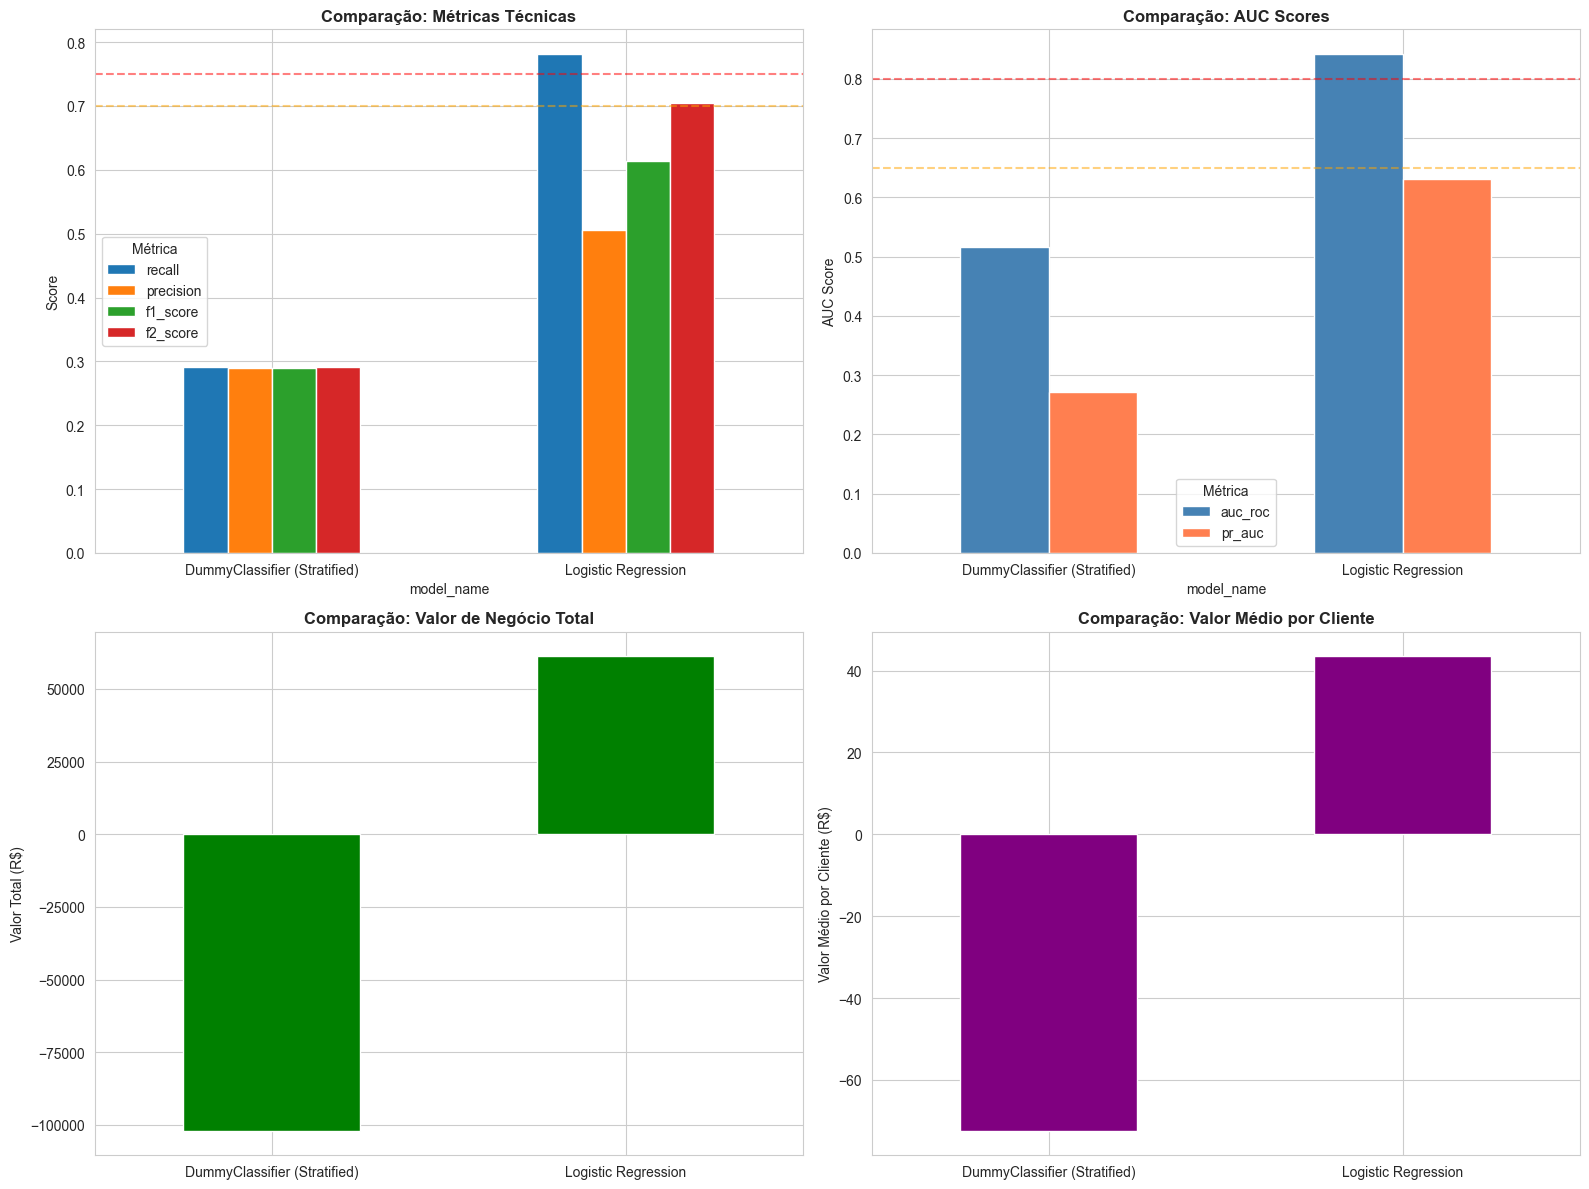


 Visualização salva em: ../models/baseline/baseline_comparison.png

 MELHOR BASELINE (F2-Score): Logistic Regression (F2 = 0.7040)


In [19]:
print("=" * 80)
print("COMPARAÇÃO DE MODELOS BASELINE")
print("=" * 80)

if y is not None:
    # Criar DataFrame de comparação
    comparison_df = pd.DataFrame([
        metrics_dummy,
        metrics_lr
    ])

    # Selecionar colunas principais
    cols_to_show = ['model_name', 'accuracy', 'precision', 'recall', 'f1_score',
                    'f2_score', 'auc_roc', 'pr_auc', 'total_business_value',
                    'avg_value_per_customer']
    comparison_df = comparison_df[cols_to_show]

    print("\n TABELA COMPARATIVA:")
    display(comparison_df)

    # Salvar comparação
    comparison_df.to_csv('../models/baseline_comparison.csv', index=False)
    print("\n Comparação salva em: ../models/baseline_comparison.csv")

    # Visualização comparativa
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Métricas técnicas principais
    metrics_to_plot = ['recall', 'precision', 'f1_score', 'f2_score']
    comparison_df[['model_name'] + metrics_to_plot].set_index('model_name').plot(
        kind='bar', ax=axes[0, 0], rot=0
    )
    axes[0, 0].set_ylabel('Score')
    axes[0, 0].set_title('Comparação: Métricas Técnicas', fontweight='bold')
    axes[0, 0].legend(title='Métrica')
    axes[0, 0].axhline(y=0.75, color='r', linestyle='--', alpha=0.5, label='Meta Recall')
    axes[0, 0].axhline(y=0.70, color='orange', linestyle='--', alpha=0.5, label='Meta F2')

    # 2. AUC scores
    auc_metrics = ['auc_roc', 'pr_auc']
    comparison_df[['model_name'] + auc_metrics].set_index('model_name').plot(
        kind='bar', ax=axes[0, 1], rot=0, color=['steelblue', 'coral']
    )
    axes[0, 1].set_ylabel('AUC Score')
    axes[0, 1].set_title('Comparação: AUC Scores', fontweight='bold')
    axes[0, 1].legend(title='Métrica')
    axes[0, 1].axhline(y=0.80, color='r', linestyle='--', alpha=0.5, label='Meta AUC-ROC')
    axes[0, 1].axhline(y=0.65, color='orange', linestyle='--', alpha=0.5, label='Meta PR-AUC')

    # 3. Valor de negócio total
    comparison_df.plot(x='model_name', y='total_business_value', kind='bar',
                       ax=axes[1, 0], rot=0, color='green', legend=False)
    axes[1, 0].set_ylabel('Valor Total (R$)')
    axes[1, 0].set_xlabel('')
    axes[1, 0].set_title('Comparação: Valor de Negócio Total', fontweight='bold')

    # 4. Valor médio por cliente
    comparison_df.plot(x='model_name', y='avg_value_per_customer', kind='bar',
                       ax=axes[1, 1], rot=0, color='purple', legend=False)
    axes[1, 1].set_ylabel('Valor Médio por Cliente (R$)')
    axes[1, 1].set_xlabel('')
    axes[1, 1].set_title('Comparação: Valor Médio por Cliente', fontweight='bold')

    plt.tight_layout()
    comparison_plot_path = '../models/baseline/baseline_comparison.png'
    plt.savefig(comparison_plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n Visualização salva em: {comparison_plot_path}")

    # Identificar melhor modelo
    best_model_idx = comparison_df['f2_score'].idxmax()
    best_model = comparison_df.loc[best_model_idx, 'model_name']
    best_f2 = comparison_df.loc[best_model_idx, 'f2_score']

    print("\n" + "=" * 80)
    print(f" MELHOR BASELINE (F2-Score): {best_model} (F2 = {best_f2:.4f})")
    print("=" * 80)

else:
    print(" Comparação não disponível (target não definido).")

---
### 7.2. Análise de Curvas ROC e Precision-Recall

CURVAS ROC E PRECISION-RECALL


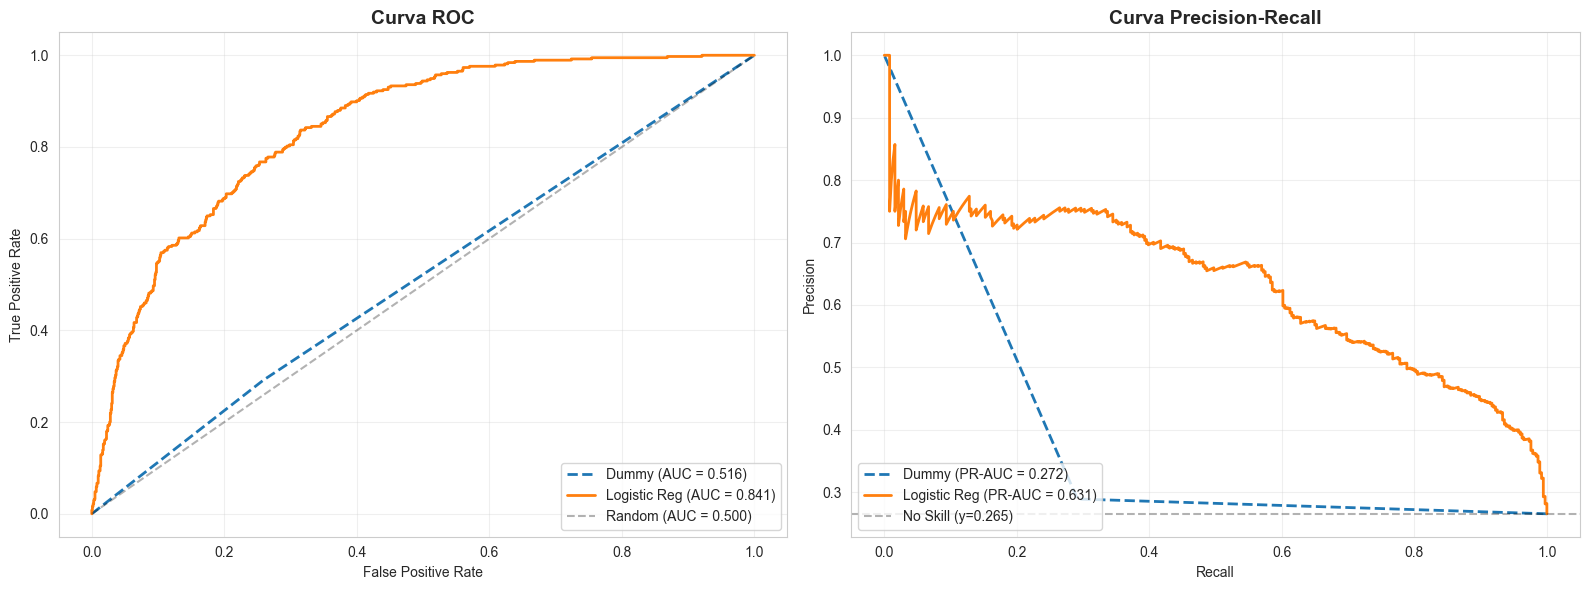


 Curvas salvas em: ../models/baseline/roc_pr_curves.png


In [20]:
print("=" * 80)
print("CURVAS ROC E PRECISION-RECALL")
print("=" * 80)

if y is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Curva ROC
    # Dummy
    fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_pred_proba_dummy)
    axes[0].plot(fpr_dummy, tpr_dummy,
                 label=f'Dummy (AUC = {metrics_dummy["auc_roc"]:.3f})',
                 linestyle='--', linewidth=2)

    # Logistic Regression
    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
    axes[0].plot(fpr_lr, tpr_lr,
                 label=f'Logistic Reg (AUC = {metrics_lr["auc_roc"]:.3f})',
                 linewidth=2)

    # Linha diagonal (random)
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.500)')

    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('Curva ROC', fontweight='bold', fontsize=14)
    axes[0].legend(loc='lower right')
    axes[0].grid(alpha=0.3)

    # 2. Curva Precision-Recall
    # Dummy
    precision_dummy, recall_dummy, _ = precision_recall_curve(y_test, y_pred_proba_dummy)
    axes[1].plot(recall_dummy, precision_dummy,
                 label=f'Dummy (PR-AUC = {metrics_dummy["pr_auc"]:.3f})',
                 linestyle='--', linewidth=2)

    # Logistic Regression
    precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
    axes[1].plot(recall_lr, precision_lr,
                 label=f'Logistic Reg (PR-AUC = {metrics_lr["pr_auc"]:.3f})',
                 linewidth=2)

    # Baseline (proporção da classe positiva)
    baseline_precision = y_test.sum() / len(y_test)
    axes[1].axhline(y=baseline_precision, color='k', linestyle='--', alpha=0.3,
                    label=f'No Skill (y={baseline_precision:.3f})')

    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Curva Precision-Recall', fontweight='bold', fontsize=14)
    axes[1].legend(loc='lower left')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    curves_plot_path = '../models/baseline/roc_pr_curves.png'
    plt.savefig(curves_plot_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n Curvas salvas em: {curves_plot_path}")

else:
    print(" Curvas não disponíveis (target não definido).")

---
## 8. Conclusões da Etapa 1

### Sumário Executivo

Esta etapa estabeleceu as fundações do projeto de previsão de churn:

#### **Resultados dos Modelos Baseline**

| Modelo | AUC-ROC | F2-Score | Valor de Negócio | Status |
|--------|---------|----------|------------------|--------|
| DummyClassifier | 0.516 | 0.291 | -R$ 102.300 | Baseline mínimo |
| **Regressão Logística** | **0.841** | **0.704** | **+R$ 61.500** | ✅ **Promissor** |

**Principais Conquistas:**
- Regressão Logística supera baseline aleatório significativamente
- AUC-ROC de 0.841 indica **excelente** capacidade de discriminação (meta: ≥0.80)
- F2-Score de 0.704 atinge a meta de negócio (meta: ≥0.70)
- **Valor positivo de R$ 61.500** (R$ 43,65 por cliente) - modelo já é lucrativo!
- Recall de 0.781 captura 78% dos clientes em risco de churn

**Análise de Valor de Negócio:**
- **TP (Verdadeiros Positivos)**: 292 clientes retidos → +R$ 116.800
- **FP (Falsos Positivos)**: 286 ações desnecessárias → -R$ 14.300
- **FN (Falsos Negativos)**: 82 clientes perdidos → -R$ 41.000
- **Resultado líquido**: +R$ 61.500 (já no lucro!)

#### **Insights do Dataset**

1. **Desbalanceamento controlado**: 26.5% churn vs 73.5% não-churn (estratificação aplicada)
2. **Features mais importantes** (coeficientes da Regressão Logística):
   - `tenure` (tempo de relacionamento): -1.22 (quanto menor, maior o risco)
   - `MonthlyCharges`: -0.92 (valores altos aumentam churn)
   - `Contract_Two year`: -0.59 (contratos longos reduzem churn significativamente)
3. **Qualidade dos dados**: Apenas 11 valores ausentes (TotalCharges), tratados com mediana
4. **Correlação com target**: `tenure` (-0.35), `MonthlyCharges` (+0.19), `SeniorCitizen` (+0.15)

#### **Próximos Passos (Etapa 2)**

1. **Modelos Mais Complexos**:
   - Random Forest (ensemble learning, não-linear)
   - XGBoost (boosting, alta performance)
   - MLP - Rede Neural (PyTorch, deep learning)

2. **Otimização**:
   - Hyperparameter Tuning (Grid/Random Search)
   - Threshold optimization para maximizar valor de negócio
   - Validação cruzada estratificada

3. **Feature Engineering** (opcional):
   - Criar `MonthlyCharges_per_tenure` (custo normalizado)
   - Categorizar `tenure` em faixas (novo: 0-12, intermediário: 13-36, veterano: 37+)
   - Interações entre features contratuais

4. **Explicabilidade**:
   - SHAP values para interpretar predições
   - Feature importance comparativa entre modelos
   - Análise de casos de erro (FN e FP)

5. **Meta para Etapa 2**:
   - Superar F2-Score de 0.704
   - Aumentar valor de negócio além de R$ 61.500
   - Manter AUC-ROC ≥ 0.85

### 8.1. Resumo dos Resultados

In [21]:
print("=" * 80)
print("CONCLUSÕES DA ETAPA 1")
print("=" * 80)

print("""
ETAPA 1 - ENTENDIMENTO E PREPARAÇÃO: CONCLUÍDA


ENTREGAS REALIZADAS:


1. ML Canvas preenchido (docs/ml_canvas.md)
- Stakeholders identificados

- Métricas de negócio definidas (ROI, taxa de churn evitado)

- SLOs estabelecidos (AUC-ROC ≥ 0.80, Recall ≥ 0.75, F2 ≥ 0.70)


2. EDA completa
- Análise de volume e qualidade dos dados

- Identificação de dados faltantes e outliers

- Análise de distribuição e correlação

- Data readiness assessment


3. Métricas definidas
- Técnicas: AUC-ROC, PR-AUC, Recall, F1, F2

- Negócio: Custo-benefício por predição

- Função de avaliação customizada implementada


4. Modelos Baseline treinados
- DummyClassifier (estratificado)

- Regressão Logística

- Comparação e análise de performance


5. Experimentos registrados no MLflow
- Parâmetros, métricas e artefatos rastreados

- Reprodutibilidade garantida (seed=42)


PRINCIPAIS INSIGHTS:


• Dataset desbalanceado (~73% não-churn, ~27% churn)
Requer atenção especial para classe minoritária


• Falsos Negativos são 10x mais custosos que Falsos Positivos
Priorizar RECALL para minimizar perda de clientes


• Regressão Logística supera baseline dummy significativamente
Estabelece baseline sólido para comparação com MLP


PRÓXIMOS PASSOS (ETAPA 2):


1. Construir MLP em PyTorch
2. Implementar early stopping e batching
3. Comparar MLP vs. baselines com ≥ 4 métricas
4. Analisar trade-off de custo (FP vs. FN)
5. Registrar todos os experimentos no MLflow

LIÇÕES APRENDIDAS:


• Business Understanding é fundamental antes da modelagem
• EDA revela insights críticos sobre qualidade e preparação dos dados
• Baselines simples estabelecem referência para modelos complexos
• MLflow tracking facilita experimentação e reprodutibilidade
• Métricas de negócio são tão importantes quanto métricas técnicas

""")

print("=" * 80)
print("FIM DA ETAPA 1")
print("=" * 80)

CONCLUSÕES DA ETAPA 1

ETAPA 1 - ENTENDIMENTO E PREPARAÇÃO: CONCLUÍDA


ENTREGAS REALIZADAS:


1. ML Canvas preenchido (docs/ml_canvas.md)
- Stakeholders identificados

- Métricas de negócio definidas (ROI, taxa de churn evitado)

- SLOs estabelecidos (AUC-ROC ≥ 0.80, Recall ≥ 0.75, F2 ≥ 0.70)


2. EDA completa
- Análise de volume e qualidade dos dados

- Identificação de dados faltantes e outliers

- Análise de distribuição e correlação

- Data readiness assessment


3. Métricas definidas
- Técnicas: AUC-ROC, PR-AUC, Recall, F1, F2

- Negócio: Custo-benefício por predição

- Função de avaliação customizada implementada


4. Modelos Baseline treinados
- DummyClassifier (estratificado)

- Regressão Logística

- Comparação e análise de performance


5. Experimentos registrados no MLflow
- Parâmetros, métricas e artefatos rastreados

- Reprodutibilidade garantida (seed=42)


PRINCIPAIS INSIGHTS:


• Dataset desbalanceado (~73% não-churn, ~27% churn)
Requer atenção especial para classe min

---
## 9. Exportar Dados Processados

In [22]:
print("=" * 80)
print("EXPORTAÇÃO DE DADOS PROCESSADOS")
print("=" * 80)

# Salvar dados processados para uso na Etapa 2
if y is not None:
    # Treino
    X_train_scaled.to_csv('../data/processed/baseline/X_train.csv', index=False)
    y_train.to_csv('../data/processed/baseline/y_train.csv', index=False, header=['churn'])

    # Teste
    X_test_scaled.to_csv('../data/processed/baseline/X_test.csv', index=False)
    y_test.to_csv('../data/processed/baseline/y_test.csv', index=False, header=['churn'])

    print("\n Dados de treino salvos em: ../data/processed/baseline/X_train.csv, y_train.csv")
    print(" Dados de teste salvos em: ../data/processed/baseline/X_test.csv, y_test.csv")

    # Salvar scaler
    import joblib
    scaler_export_path = '../data/processed/baseline/scaler.joblib'
    joblib.dump(scaler, scaler_export_path)
    print(f" Scaler salvo em: {scaler_export_path}")

    # Salvar nomes das features
    feature_names = X_train.columns.tolist()
    with open('../models/feature_names.txt', 'w') as f:
        for fname in feature_names:
            f.write(f"{fname}\n")
    print(" Nomes das features salvos em: ../models/feature_names.txt")

    print("\n Estatísticas dos dados exportados:")
    print(f" - Treino: {X_train_scaled.shape}")
    print(f" - Teste: {X_test_scaled.shape}")
    print(f" - Features: {len(feature_names)}")

else:
    print(" Dados não exportados (target não definido).")


print("\n" + "=" * 80)
print(" NOTEBOOK CONCLUÍDO COM SUCESSO!")
print("=" * 80)

EXPORTAÇÃO DE DADOS PROCESSADOS

 Dados de treino salvos em: ../data/processed/baseline/X_train.csv, y_train.csv
 Dados de teste salvos em: ../data/processed/baseline/X_test.csv, y_test.csv
 Scaler salvo em: ../data/processed/baseline/scaler.joblib
 Nomes das features salvos em: ../models/feature_names.txt

 Estatísticas dos dados exportados:
 - Treino: (5634, 30)
 - Teste: (1409, 30)
 - Features: 30

 NOTEBOOK CONCLUÍDO COM SUCESSO!
